**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
sns.set(style="whitegrid")

**Load Dataset**

In [2]:
# Load the master dataset

df = pd.read_csv("Master_DS.csv")

# Display first five rows
df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
0,1995-01,1995,January,6.63,2.4,8.9,19.6,0.5,78866,399,162
1,1995-02,1995,February,6.63,2.4,8.9,19.6,0.5,80654,452,186
2,1995-03,1995,March,6.63,2.6,8.8,19.6,0.5,74872,535,158
3,1995-04,1995,April,6.63,2.3,8.8,19.8,0.2,75112,303,153
4,1995-05,1995,May,6.63,2.5,8.7,19.8,0.2,70629,276,182


**Number of Observations**



In [3]:
print("Dataset Shape")
print("-"*40)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
----------------------------------------
Rows    : 372
Columns : 11


**Data Types**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     372 non-null    object 
 1   Year                     372 non-null    int64  
 2   Month                    372 non-null    object 
 3   Bank_Rate                372 non-null    float64
 4   CPI                      372 non-null    float64
 5   Unemployment_Rate        372 non-null    float64
 6   House_Price_Index        372 non-null    float64
 7   GDP_Growth               372 non-null    float64
 8   Mortgage_Approvals       372 non-null    int64  
 9   Net_Consumer_Credit      372 non-null    int64  
 10  Net_Credit_Card_Lending  372 non-null    int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 32.1+ KB


**Check Data Types**

In [5]:
df.dtypes

,0
Date,object
Year,int64
Month,object
Bank_Rate,float64
CPI,float64
Unemployment_Rate,float64
House_Price_Index,float64
GDP_Growth,float64
Mortgage_Approvals,int64
Net_Consumer_Credit,int64


**Missing Values**

In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Date,0,0.0
Year,0,0.0
Month,0,0.0
Bank_Rate,0,0.0
CPI,0,0.0
Unemployment_Rate,0,0.0
House_Price_Index,0,0.0
GDP_Growth,0,0.0
Mortgage_Approvals,0,0.0
Net_Consumer_Credit,0,0.0


**Duplicate Rows**

In [7]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


**Descriptive Statistics**

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,372.0,2010.000000,8.956318,1995.0,2002.000,2010.00,2018.000,2025.0
Bank_Rate,372.0,3.089597,2.459424,0.1,0.500,4.00,5.250,7.5
CPI,372.0,2.463978,1.916574,-0.1,1.400,2.10,2.900,11.1
Unemployment_Rate,372.0,5.702957,1.444524,3.6,4.700,5.20,6.700,8.9
House_Price_Index,372.0,60.734140,24.590978,19.6,42.425,60.25,79.725,104.3
GDP_Growth,372.0,0.496774,2.515835,-19.9,0.200,0.60,0.800,17.0
Mortgage_Approvals,372.0,76992.577957,24305.992379,9369.0,61339.000,70284.00,96648.250,132788.0
Net_Consumer_Credit,372.0,597.295699,546.443994,-2893.0,393.750,725.00,937.000,1551.0
Net_Credit_Card_Lending,372.0,341.236559,459.321917,-4946.0,182.750,353.50,581.500,1304.0


**Correlation Matrix**

In [9]:
corr = df.select_dtypes(include=np.number).corr()

corr

,Year,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
Year,1.000000,-0.628985,0.370518,-0.522182,0.977708,-0.049093,-0.556263,-0.101137,-0.074242
Bank_Rate,-0.628985,1.000000,-0.051181,0.061266,-0.540452,0.029029,0.501160,0.322293,0.245044
CPI,0.370518,-0.051181,1.000000,-0.085725,0.420572,-0.043140,-0.404781,-0.120318,0.135632
Unemployment_Rate,-0.522182,0.061266,-0.085725,1.000000,-0.591912,0.036694,-0.142712,-0.416167,-0.199788
House_Price_Index,0.977708,-0.540452,0.420572,-0.591912,1.000000,-0.040832,-0.476356,-0.060528,-0.026507
GDP_Growth,-0.049093,0.029029,-0.043140,0.036694,-0.040832,1.000000,0.266904,0.313570,0.396571
Mortgage_Approvals,-0.556263,0.501160,-0.404781,-0.142712,-0.476356,0.266904,1.000000,0.464592,0.199217
Net_Consumer_Credit,-0.101137,0.322293,-0.120318,-0.416167,-0.060528,0.313570,0.464592,1.000000,0.601509
Net_Credit_Card_Lending,-0.074242,0.245044,0.135632,-0.199788,-0.026507,0.396571,0.199217,0.601509,1.000000


**Correlation Heatmap**

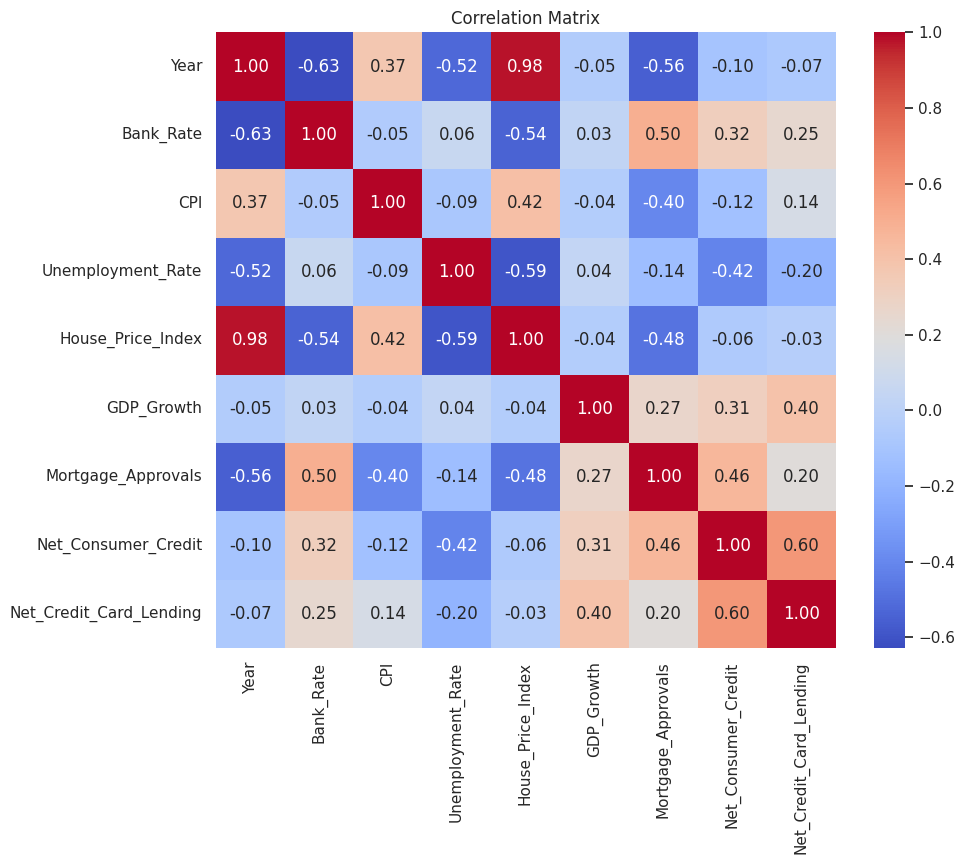

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Detect Outliers (IQR)**

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outliers)} outliers")

Year : 0 outliers
Bank_Rate : 0 outliers
CPI : 24 outliers
Unemployment_Rate : 0 outliers
House_Price_Index : 0 outliers
GDP_Growth : 24 outliers
Mortgage_Approvals : 0 outliers
Net_Consumer_Credit : 19 outliers
Net_Credit_Card_Lending : 11 outliers


**Boxplots**

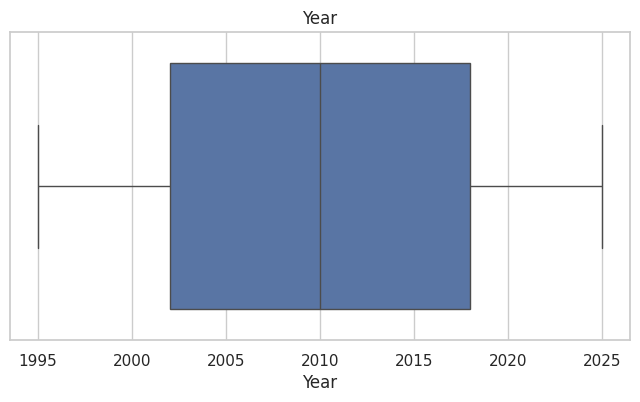

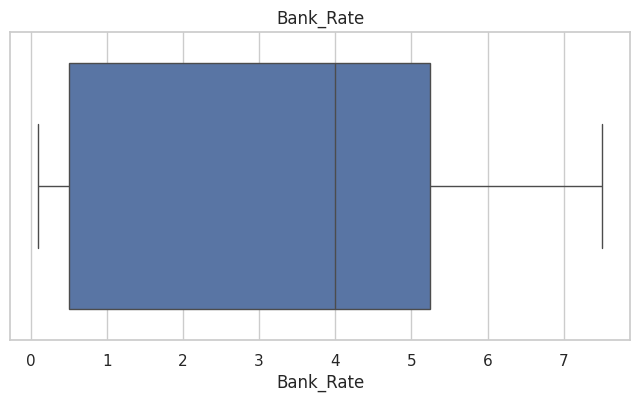

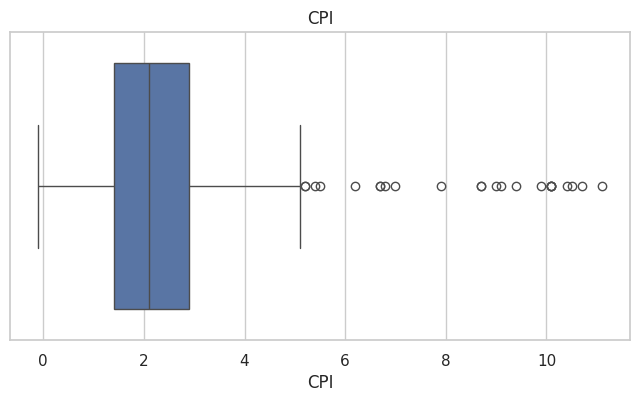

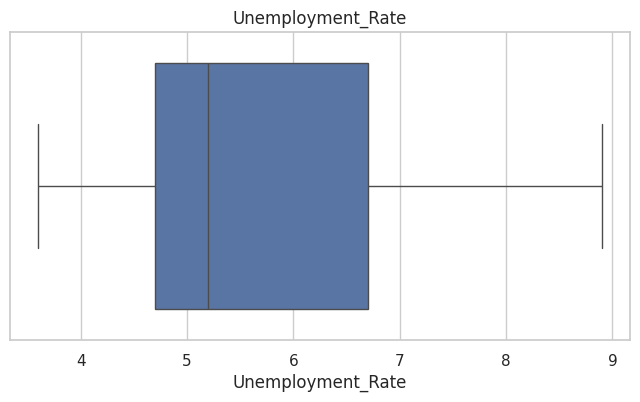

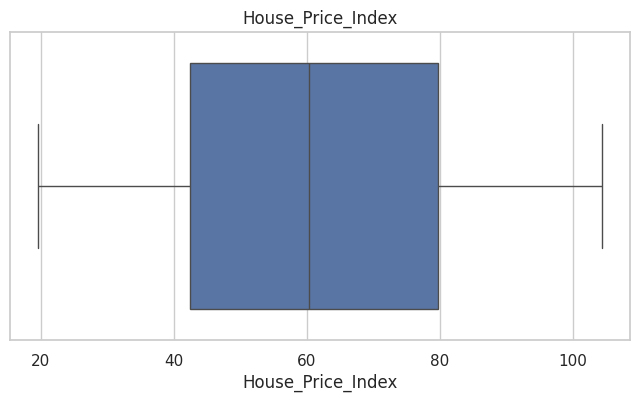

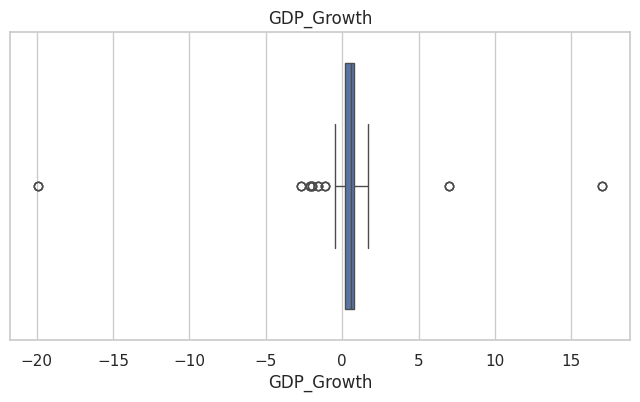

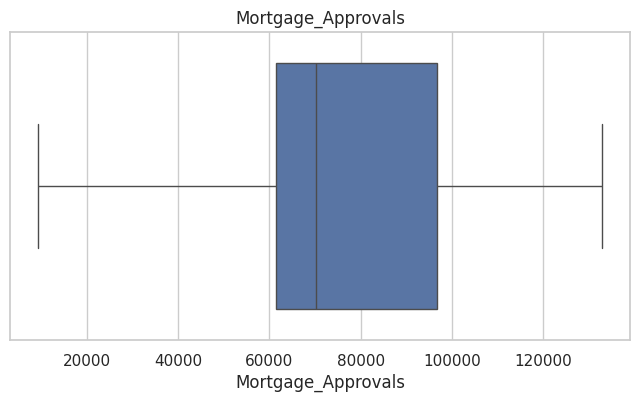

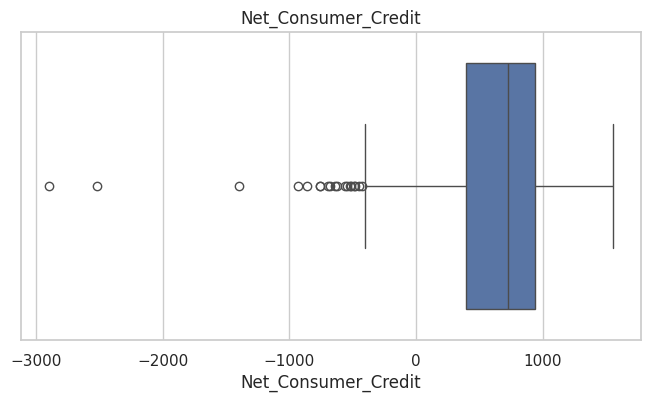

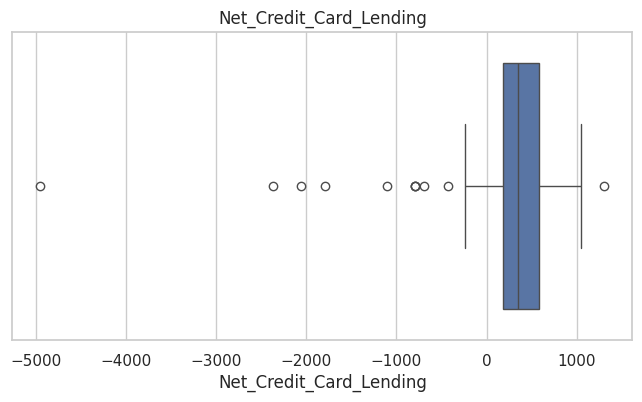

In [12]:
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

**Scatter Plots**

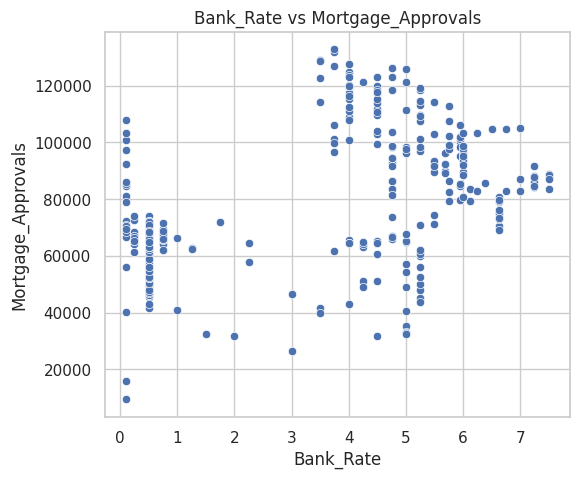

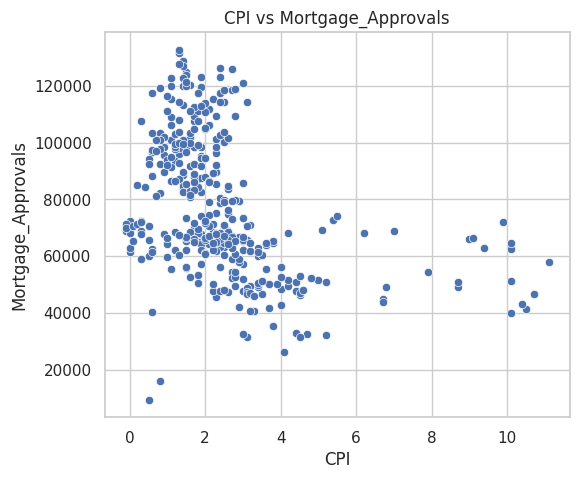

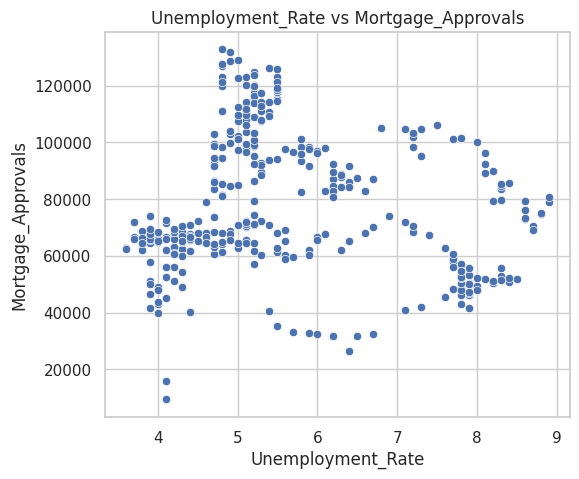

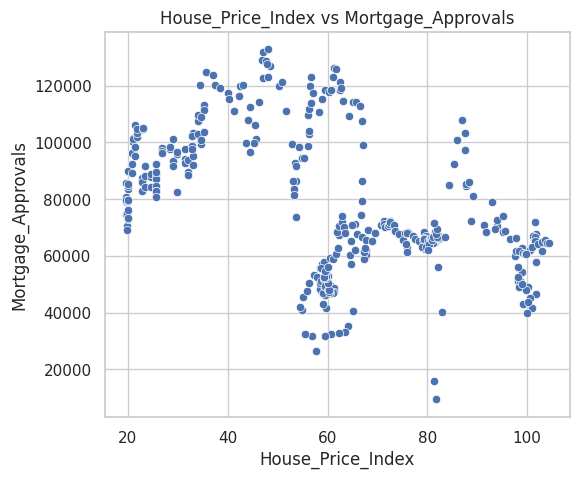

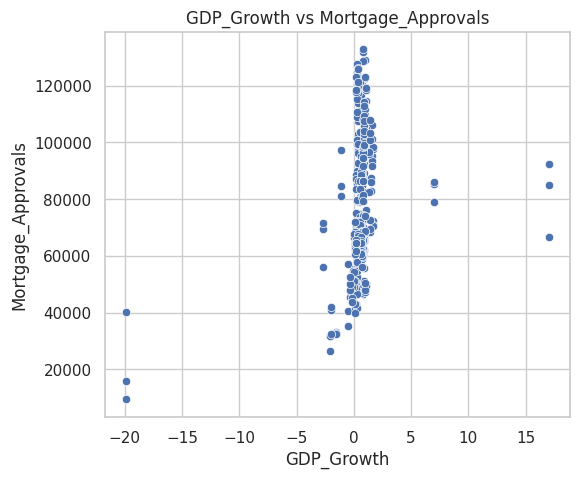

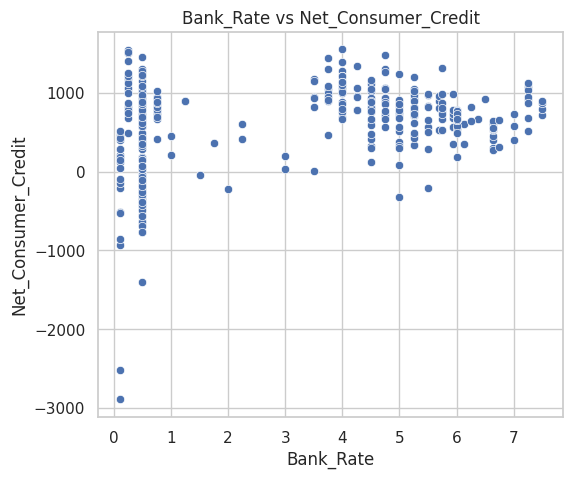

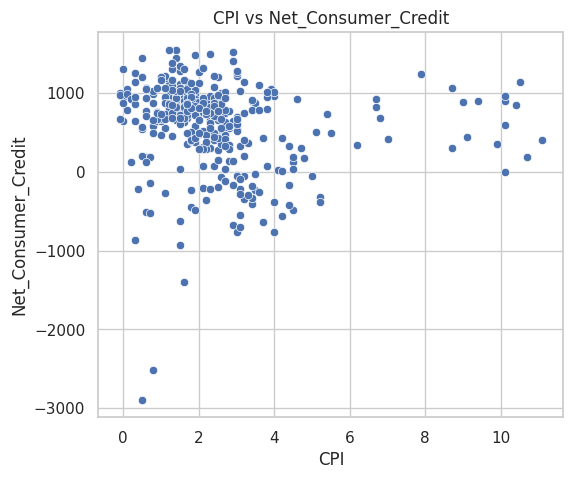

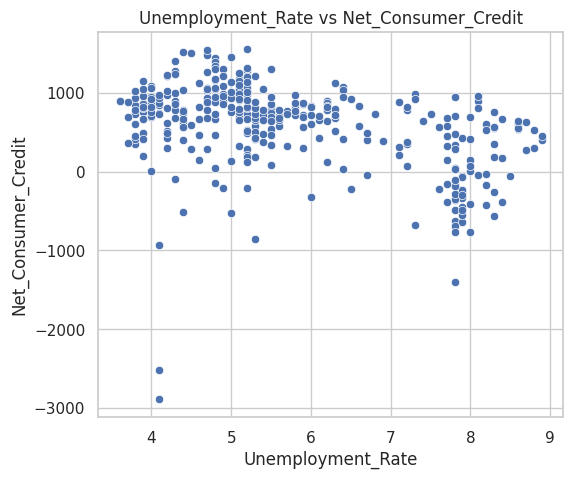

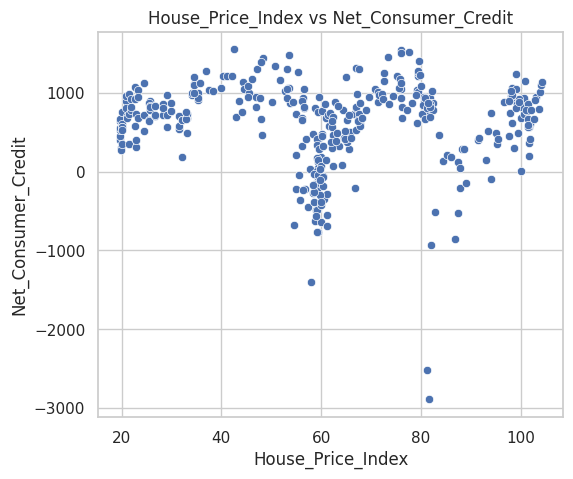

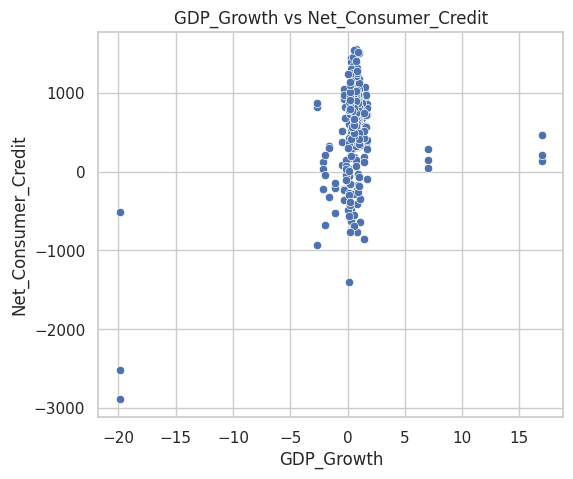

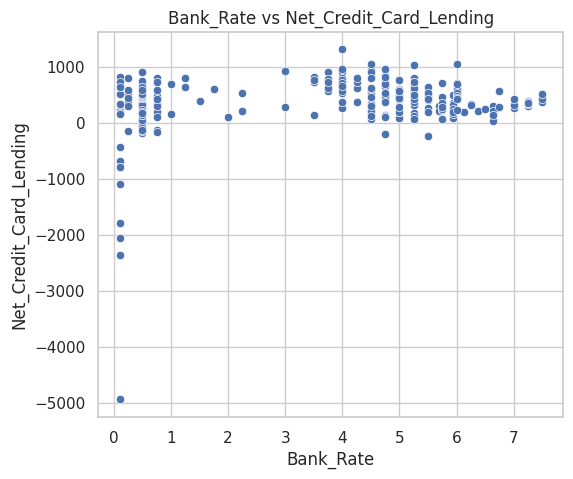

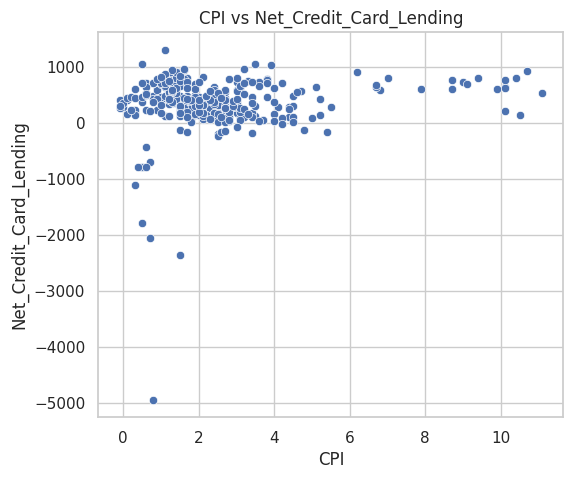

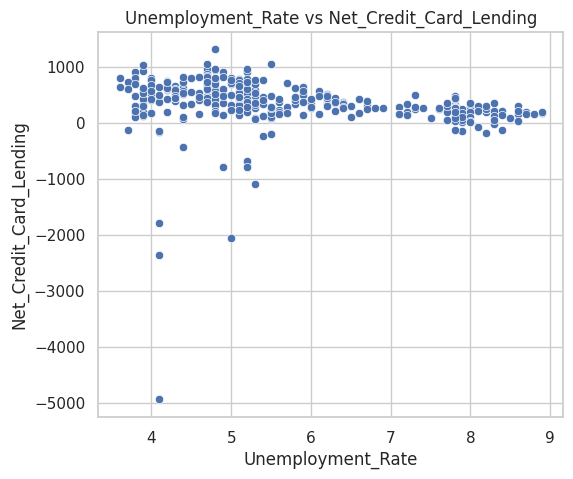

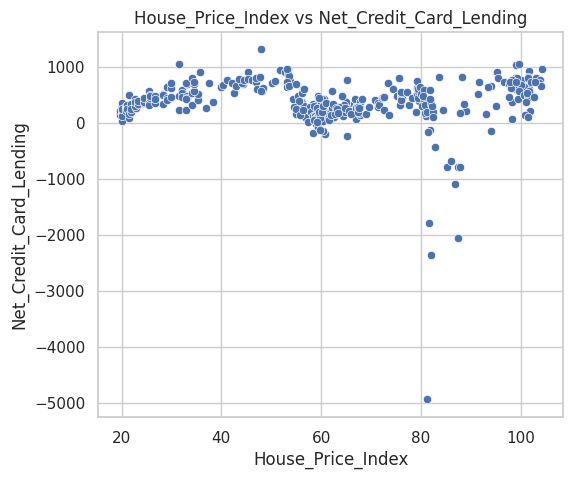

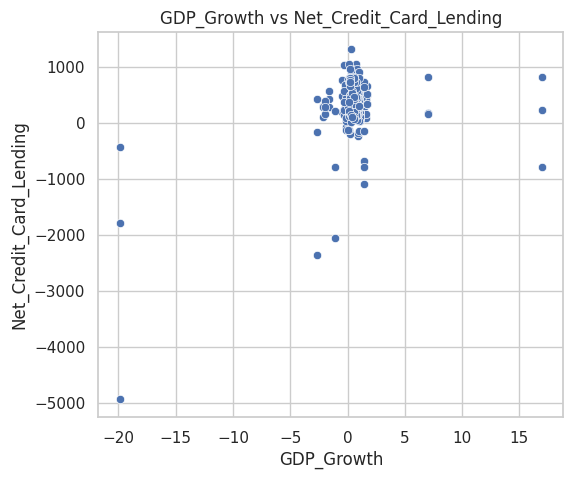

In [17]:
targets = [
    "Mortgage_Approvals",
    "Net_Consumer_Credit",
    "Net_Credit_Card_Lending"
]

features = [
    "Bank_Rate",
    "CPI",
    "Unemployment_Rate",
    "House_Price_Index",
    "GDP_Growth"
]

for target in targets:

    for feature in features:

        plt.figure(figsize=(6,5))

        sns.scatterplot(data=df,
                        x=feature,
                        y=target)

        plt.title(f"{feature} vs {target}")

        plt.show()